# Week 4a.1 — LangGraph Basics

We've seen how to build an agent with `create_agent`, which runs the whole propose-execute-return loop for us. Today we open the hood under the function call. `create_agent` is built on [**LangGraph**](https://www.langchain.com/langgraph), a library for describing applications as graphs. If we understand the graph layer, we can build flows that `create_agent` cannot give us: workflows, branching logic, and eventually agents with memory and custom state.

We'll start by building a first graph, a sequential chain, and a router.

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
assert os.getenv("GOOGLE_API_KEY"), "No GOOGLE_API_KEY found."
print("API key loaded")

## 0. Model Setup

Execute one of the following to define the model.

If using Ollama, you will need to start it first (simply open the chat UI and send a message):
- https://docs.langchain.com/oss/python/integrations/chat/ollama

Verify that Ollama is serving a model:
- http://localhost:11434/

In [ ]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="qwen3.5:4b", reasoning=False)

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="gpt-4.1-mini")

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

## 1. The three core elements

Every LangGraph application is built from three things:

- **State**: a shared data structure that every step can read and update. We define its shape with a `TypedDict`.
- **Nodes**: plain Python functions. A node receives the current state and returns a dictionary containing only the keys it wants to update.
- **Edges**: connections that decide which node runs next. `START` and `END` mark where execution enters and leaves the graph.

Docs: https://docs.langchain.com/oss/python/langgraph/graph-api

In [2]:
from typing_extensions import TypedDict

class State(TypedDict):
    text: str

A node is an ordinary function. It takes the state and returns the update it wants to make. Nothing else.

In [3]:
def add_greeting(state: State) -> dict:
    return {"text": "Hello, " + state["text"]}

def shout(state: State) -> dict:
    return {"text": state["text"].upper() + "!"}

## 2. Build the first graph

Construction is always the same recipe: create a builder around the state, add nodes, add edges, compile.

This is the graph we are about to build:

![](figures/graph_sequential.png)

In [4]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("add_greeting", add_greeting)
builder.add_node("shout", shout)

builder.add_edge(START, "add_greeting")
builder.add_edge("add_greeting", "shout")
builder.add_edge("shout", END)

graph = builder.compile()

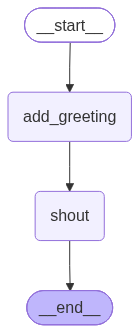

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
graph.invoke({"text": "agentic AI class"})

{'text': 'HELLO, AGENTIC AI CLASS!'}

`invoke` takes a dictionary shaped like the state and returns the final state. Each node's return value overwrote the `text` key in turn.

Notice there is no LLM anywhere yet. A graph is just orchestration; what runs inside each node is up to us.

## 3. A sequential chain

Now put a model inside the nodes. This is the **prompt chaining** pattern from the Week 1 reading (Building Effective Agents): each step's output becomes the next step's input, and the route through the graph is fixed.

![](figures/graph_chain.png)

In [7]:
class JokeState(TypedDict):
    topic: str
    joke: str
    improved_joke: str

In [9]:
def write_joke(state: JokeState) -> dict:
    response = model.invoke(f"Write a short, clean joke about {state['topic']}.")
    return {"joke": response.text}

One practical detail: we store `response.text`, not `response.content`. Some providers (Gemini included) return `content` as a list of content blocks rather than a plain string; `.text` always gives you the reply as a string.

In [ ]:
#TODO: write the second node, improve_joke.
# It should ask the model to make state['joke'] funnier by adding a follow-up line,
# and return the result under the key 'improved_joke'.


In [ ]:
chain_builder = StateGraph(JokeState)

chain_builder.add_node("write_joke", write_joke)
chain_builder.add_node("improve_joke", improve_joke)

chain_builder.add_edge(START, "write_joke")
chain_builder.add_edge("write_joke", "improve_joke")
chain_builder.add_edge("improve_joke", END)

chain = chain_builder.compile()
display(Image(chain.get_graph().draw_mermaid_png()))

In [ ]:
result = chain.invoke({"topic": "final exams"})

print(result["joke"])
print("---")
print(result["improved_joke"])

The model did the writing, but it made no decisions about control flow. The route was fixed when we drew the edges. That makes this a **workflow**, not an agent.

## 4. Messages as state

Chat applications need one specific behavior from state: the conversation must **grow**. With a plain `TypedDict`, each node's return overwrites the key, which would erase the history.

LangGraph solves this with reducers: a rule attached to a state key that says how updates combine with what is already there. For chat there is a ready-made state, `MessagesState`, with a single `messages` key whose reducer **appends** new messages instead of replacing the list.

The whole graph this time is a single node:

![](figures/graph_chatbot.png)

In [ ]:
from langgraph.graph import MessagesState

def chatbot(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"])]}

In [ ]:
from langchain.messages import HumanMessage

chat_builder = StateGraph(MessagesState)
chat_builder.add_node("chatbot", chatbot)
chat_builder.add_edge(START, "chatbot")
chat_builder.add_edge("chatbot", END)

chat_graph = chat_builder.compile()

result = chat_graph.invoke({"messages": [HumanMessage(content="What is a graph, in one sentence?")]})

for m in result["messages"]:
    m.pretty_print()

Both messages are there: the model's reply was appended to the human message, not written over it. This one-node graph is a complete chatbot, and `MessagesState` is the state we will use for agents.

## 5. A router

So far every edge was fixed. A **conditional edge** makes the first real decision: a function inspects the state and returns the name of the node to run next.

The example: a support desk that triages incoming messages to a billing team or a general queue. Keep this scenario in mind; in Week 4b we rebuild the Week 3b support agent in LangGraph.

The target graph. In these diagrams, solid arrows are fixed edges; **dashed red arrows are conditional edges**, where the next node is decided at runtime:

![](figures/graph_router.png)

In [ ]:
class SupportState(TypedDict):
    message: str
    reply: str

def billing(state: SupportState) -> dict:
    return {"reply": "Billing team: we will review the charge on your account."}

def general(state: SupportState) -> dict:
    return {"reply": "Support: thanks for reaching out, how can we help?"}

In [ ]:
def route(state: SupportState) -> str:
    text = state["message"].lower()
    if any(word in text for word in ["refund", "charge", "billing", "payment"]):
        return "billing"
    return "general"

In [ ]:
router_builder = StateGraph(SupportState)

router_builder.add_node("billing", billing)
router_builder.add_node("general", general)

router_builder.add_conditional_edges(START, route, {"billing": "billing", "general": "general"})
router_builder.add_edge("billing", END)
router_builder.add_edge("general", END)

router = router_builder.compile()
display(Image(router.get_graph().draw_mermaid_png()))

In [ ]:
print(router.invoke({"message": "I want a refund for my order"})["reply"])
print(router.invoke({"message": "Do you ship to Canada?"})["reply"])

The routing logic is hard-coded keywords, and keywords are brittle. "My card was hit twice for one order" is clearly a billing problem, but none of our keywords appear in it. Let the model classify instead.

In [ ]:
#TODO: write llm_route, a routing function that asks the model to classify
# state['message'] and answers with exactly one word: billing or general.
# Return 'billing' if the model says billing, otherwise 'general'.
# Hint: read the reply with response.text, then strip() and lower() it.


In [ ]:
llm_router_builder = StateGraph(SupportState)

llm_router_builder.add_node("billing", billing)
llm_router_builder.add_node("general", general)

llm_router_builder.add_conditional_edges(START, llm_route, {"billing": "billing", "general": "general"})
llm_router_builder.add_edge("billing", END)
llm_router_builder.add_edge("general", END)

llm_router = llm_router_builder.compile()

print(llm_router.invoke({"message": "My card was hit twice for one order"})["reply"])
print(llm_router.invoke({"message": "Do you ship to Canada?"})["reply"])

Same graph shape, smarter decision. One decision per run, though: the router picks a branch once and the graph ends.

An agent needs more: decide, act, look at the result, decide again. That takes a loop in the graph, and the model's **tool calls** become the routing signal. That is the next notebook.